#  PR 3
## Classical Image Processing → Face Detection → YOLO Object Detection



### Objective
Build one integrated computer-vision workflow covering morphological operations, bitwise operations, image histograms, YuNet face detection, YOLOv8 object detection, and a final real-time comparison.




## Task 1 — Environment Setup, Image I/O & Morphological Operations

**Objective:** Load images correctly, create a binary image, and study erosion, dilation, opening, closing, and kernel-shape/size effects.

**Expected output:** image information, original/binary comparison, 1×5 morphology grid, and 3×3 kernel comparison grid.


OpenCV version: 5.0.0
Colour shape: (360, 520, 3) dtype: uint8
Gray shape: (360, 520) dtype: uint8


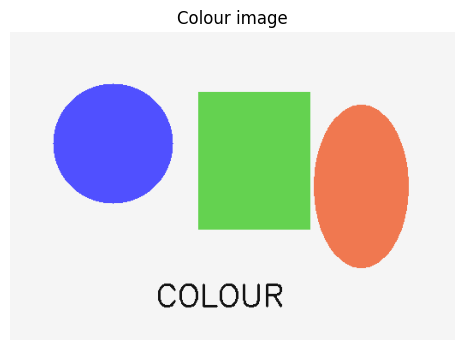

In [11]:
# 1.1 Environment setup
# Run this once in a fresh environment. The project brief specifies OpenCV 5.0.0,
# opencv-contrib, Ultralytics, Matplotlib and NumPy.
# !pip install opencv-python==5.0.0.* opencv-contrib-python==5.0.0.* ultralytics matplotlib numpy

import os, time, urllib.request
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)

BASE = Path.cwd()
DATA = BASE / "data" / "images"
MODELS = BASE / "data" / "models"
PLOTS = BASE / "plots"
DATA.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

def show(img, title="", ax=None):
    if ax is None:
        plt.figure(figsize=(6,4))
        ax = plt.gca()
    if img.ndim == 3:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

color_path = DATA / "04_color_scene.png"
gray_path = DATA / "01_noisy_objects.png"
color_img = cv2.imread(str(color_path))
gray_source = cv2.imread(str(gray_path), cv2.IMREAD_GRAYSCALE)

print("Colour shape:", color_img.shape, "dtype:", color_img.dtype)
print("Gray shape:", gray_source.shape, "dtype:", gray_source.dtype)
show(color_img, "Colour image")
plt.show()


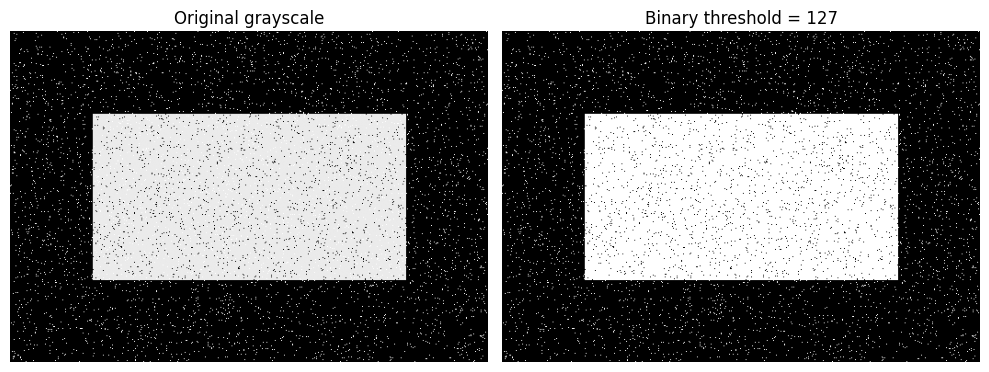

In [12]:
# 1.2 Binarize a test image
gray = cv2.cvtColor(cv2.imread(str(gray_path)), cv2.COLOR_GRAY2BGR) if False else gray_source
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].imshow(gray, cmap="gray"); ax[0].set_title("Original grayscale"); ax[0].axis("off")
ax[1].imshow(binary, cmap="gray"); ax[1].set_title("Binary threshold = 127"); ax[1].axis("off")
plt.tight_layout()
plt.savefig(PLOTS / "binary_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


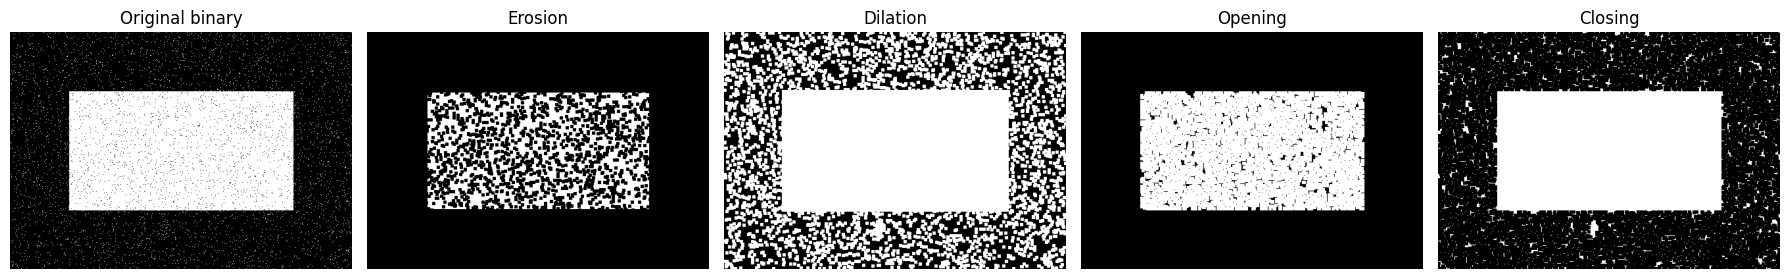

In [13]:
# 1.3 Four morphological operations
kernel = np.ones((5,5), np.uint8)

eroded = cv2.erode(binary, kernel, iterations=1)
dilated = cv2.dilate(binary, kernel, iterations=1)
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

fig, ax = plt.subplots(1, 5, figsize=(18,4))
images = [binary, eroded, dilated, opened, closed]
titles = ["Original binary", "Erosion", "Dilation", "Opening", "Closing"]
for a, im, t in zip(ax, images, titles):
    a.imshow(im, cmap="gray"); a.set_title(t); a.axis("off")
plt.tight_layout()
plt.savefig(PLOTS / "morphology_grid.png", dpi=150, bbox_inches="tight")
plt.show()


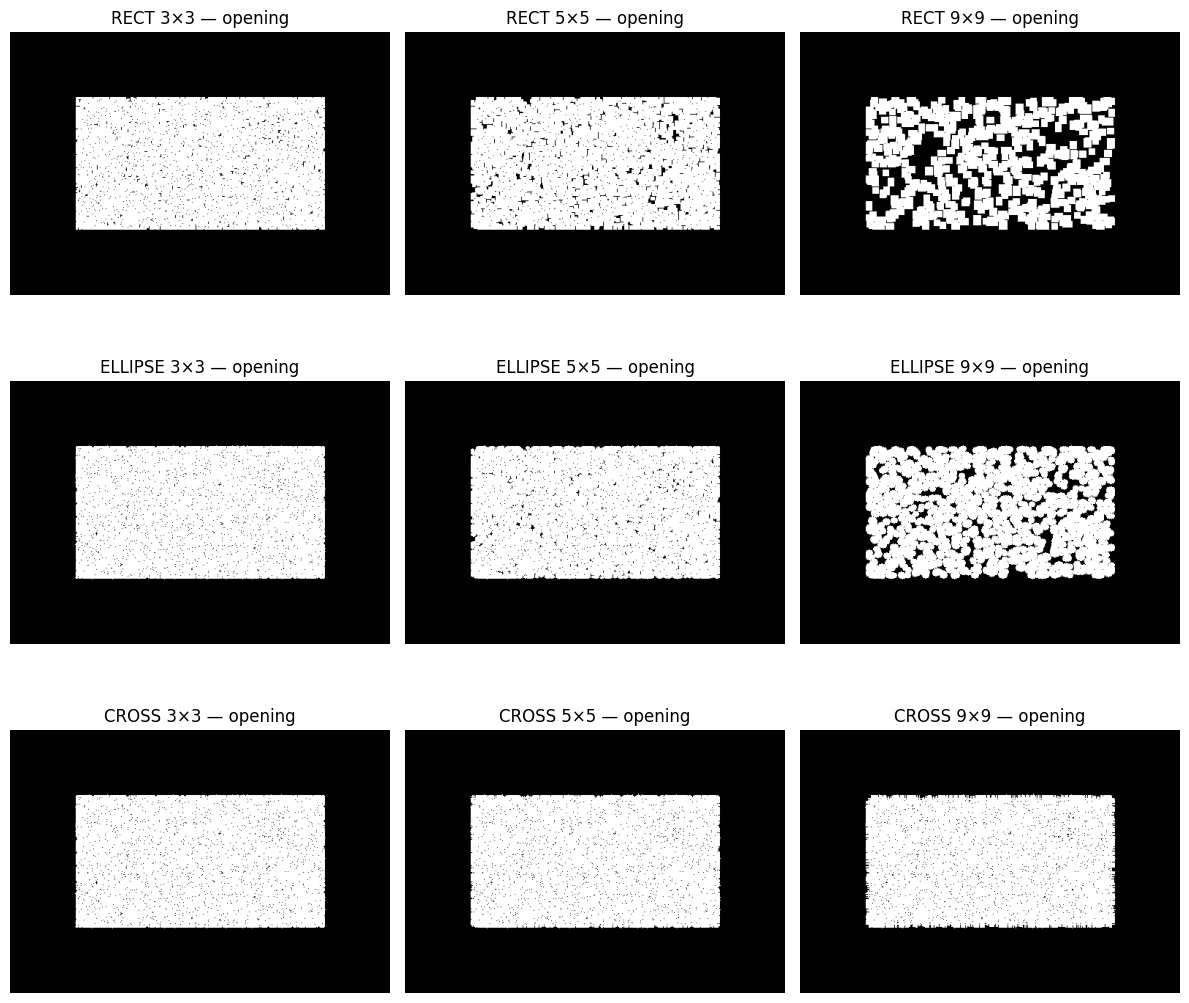

Practical observation: for salt-and-pepper noise, a small 3×3 or 5×5 kernel is usually preferred.
A larger 9×9 kernel removes more noise but can damage thin object boundaries.


In [14]:
# 1.4 Kernel shape × size comparison
# Rows = RECT, ELLIPSE, CROSS; columns = 3×3, 5×5, 9×9.
shapes = {
    "RECT": cv2.MORPH_RECT,
    "ELLIPSE": cv2.MORPH_ELLIPSE,
    "CROSS": cv2.MORPH_CROSS
}
sizes = [3, 5, 9]

fig, ax = plt.subplots(3, 3, figsize=(12,11))
for r, (shape_name, shape_code) in enumerate(shapes.items()):
    for c, size in enumerate(sizes):
        k = cv2.getStructuringElement(shape_code, (size, size))
        result = cv2.morphologyEx(binary, cv2.MORPH_OPEN, k)
        ax[r,c].imshow(result, cmap="gray")
        ax[r,c].set_title(f"{shape_name} {size}×{size} — opening")
        ax[r,c].axis("off")
plt.tight_layout()
plt.savefig(PLOTS / "kernel_comparison_grid.png", dpi=150, bbox_inches="tight")
plt.show()

print("Practical observation: for salt-and-pepper noise, a small 3×3 or 5×5 kernel is usually preferred.")
print("A larger 9×9 kernel removes more noise but can damage thin object boundaries.")


### 1.5 WHY morphology works

- **Erosion** behaves like a local minimum filter: white regions shrink and small bright noise can disappear.
- **Dilation** behaves like a local maximum filter: white regions grow and small dark gaps can be filled.
- **Opening = erosion → dilation:** useful for removing small isolated bright noise while retaining the main shape.
- **Closing = dilation → erosion:** useful for filling small holes/gaps and reconnecting nearby bright regions.

**Real scenarios before detection**
- Opening: remove salt-and-pepper noise from a surveillance/inspection mask before contour extraction.
- Closing: fill small holes in a person/object segmentation mask before passing the cleaned region to a detector.

The project brief explicitly asks for these min/max interpretations and real downstream-detector scenarios. fileciteturn0file0L109-L120


## Task 2 — Bitwise Operations & Image Histograms

**Objective:** Demonstrate AND/OR/XOR/NOT, use a mask on a real image, compute grayscale and colour histograms, and study brightness/contrast.

**Expected output:** 2×3 bitwise grid, masked-overlay examples, grayscale + B/G/R histograms, and brightness/contrast histogram comparison.


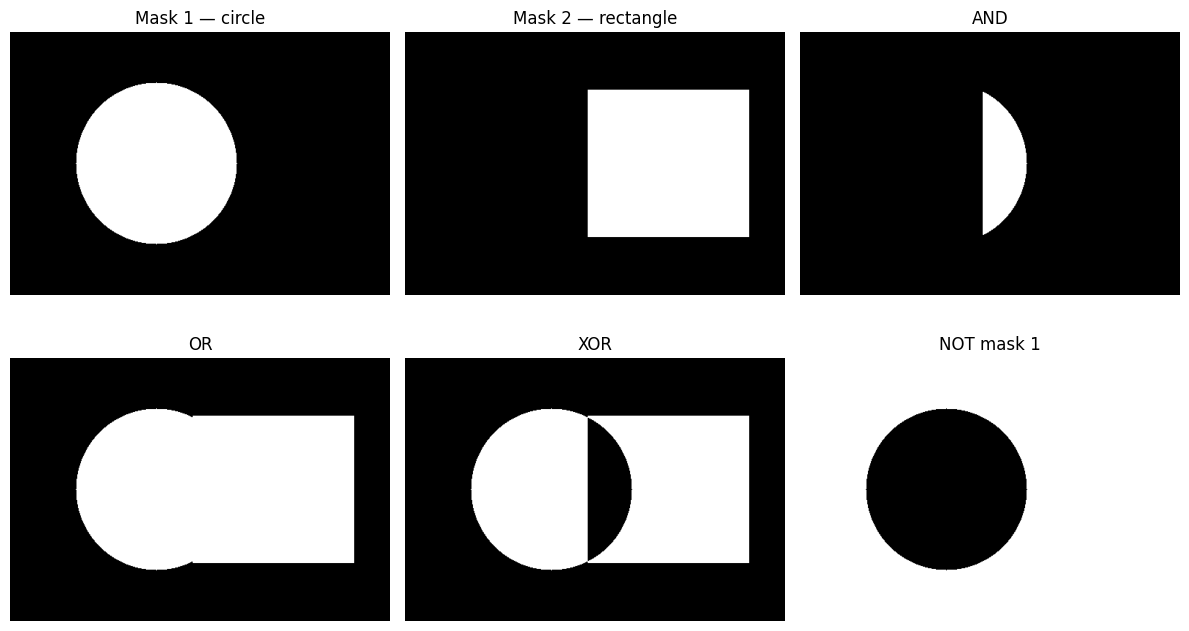

In [15]:
# 2.1 Bitwise AND / OR / XOR / NOT
h, w = 360, 520
mask1 = np.zeros((h,w), dtype=np.uint8)
mask2 = np.zeros((h,w), dtype=np.uint8)
cv2.circle(mask1, (200,180), 110, 255, -1)
cv2.rectangle(mask2, (250,80), (470,280), 255, -1)

and_img = cv2.bitwise_and(mask1, mask2)
or_img = cv2.bitwise_or(mask1, mask2)
xor_img = cv2.bitwise_xor(mask1, mask2)
not_img = cv2.bitwise_not(mask1)

fig, ax = plt.subplots(2,3, figsize=(12,7))
items = [
    (mask1, "Mask 1 — circle"), (mask2, "Mask 2 — rectangle"),
    (and_img, "AND"), (or_img, "OR"), (xor_img, "XOR"), (not_img, "NOT mask 1")
]
for a,(im,t) in zip(ax.ravel(), items):
    a.imshow(im, cmap="gray"); a.set_title(t); a.axis("off")
plt.tight_layout()
plt.savefig(PLOTS / "bitwise_grid.png", dpi=150, bbox_inches="tight")
plt.show()


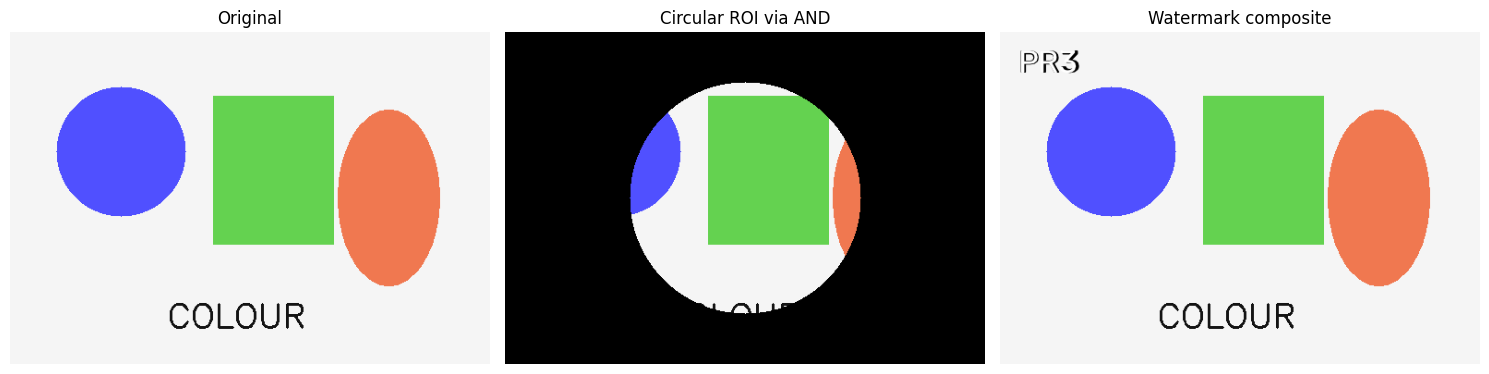

In [16]:
# 2.2 Applied use-case: masked overlay
photo = cv2.imread(str(color_path))
roi_mask = np.zeros(photo.shape[:2], dtype=np.uint8)
cv2.circle(roi_mask, (photo.shape[1]//2, photo.shape[0]//2), 125, 255, -1)

masked_region = cv2.bitwise_and(photo, photo, mask=roi_mask)

# Simple watermark/logo-like composite using a small binary patch
overlay = photo.copy()
cv2.putText(overlay, "PR3", (20, 45), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,0,0), 3)
cv2.putText(overlay, "PR3", (20, 45), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255,255,255), 1)

fig, ax = plt.subplots(1,3, figsize=(15,4))
for a,im,t in zip(ax, [photo, masked_region, overlay], ["Original", "Circular ROI via AND", "Watermark composite"]):
    a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); a.set_title(t); a.axis("off")
plt.tight_layout()
plt.savefig(PLOTS / "masked_overlay.png", dpi=150, bbox_inches="tight")
plt.show()


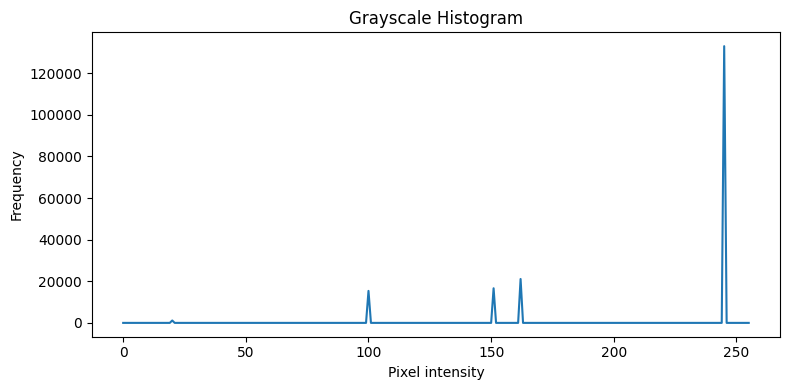

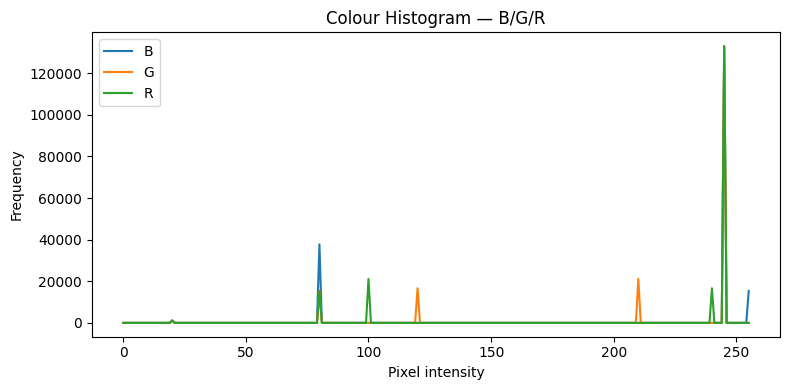

In [17]:
# 2.3 Grayscale and per-channel colour histograms
gray_color = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)
gray_hist = cv2.calcHist([gray_color], [0], None, [256], [0,256])

plt.figure(figsize=(8,4))
plt.plot(gray_hist)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(PLOTS / "grayscale_histogram.png", dpi=150)
plt.show()

plt.figure(figsize=(8,4))
channel_names = ["B", "G", "R"]
for i, name in enumerate(channel_names):
    hist = cv2.calcHist([color_img], [i], None, [256], [0,256])
    plt.plot(hist, label=name)
plt.title("Colour Histogram — B/G/R")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS / "color_histogram.png", dpi=150)
plt.show()


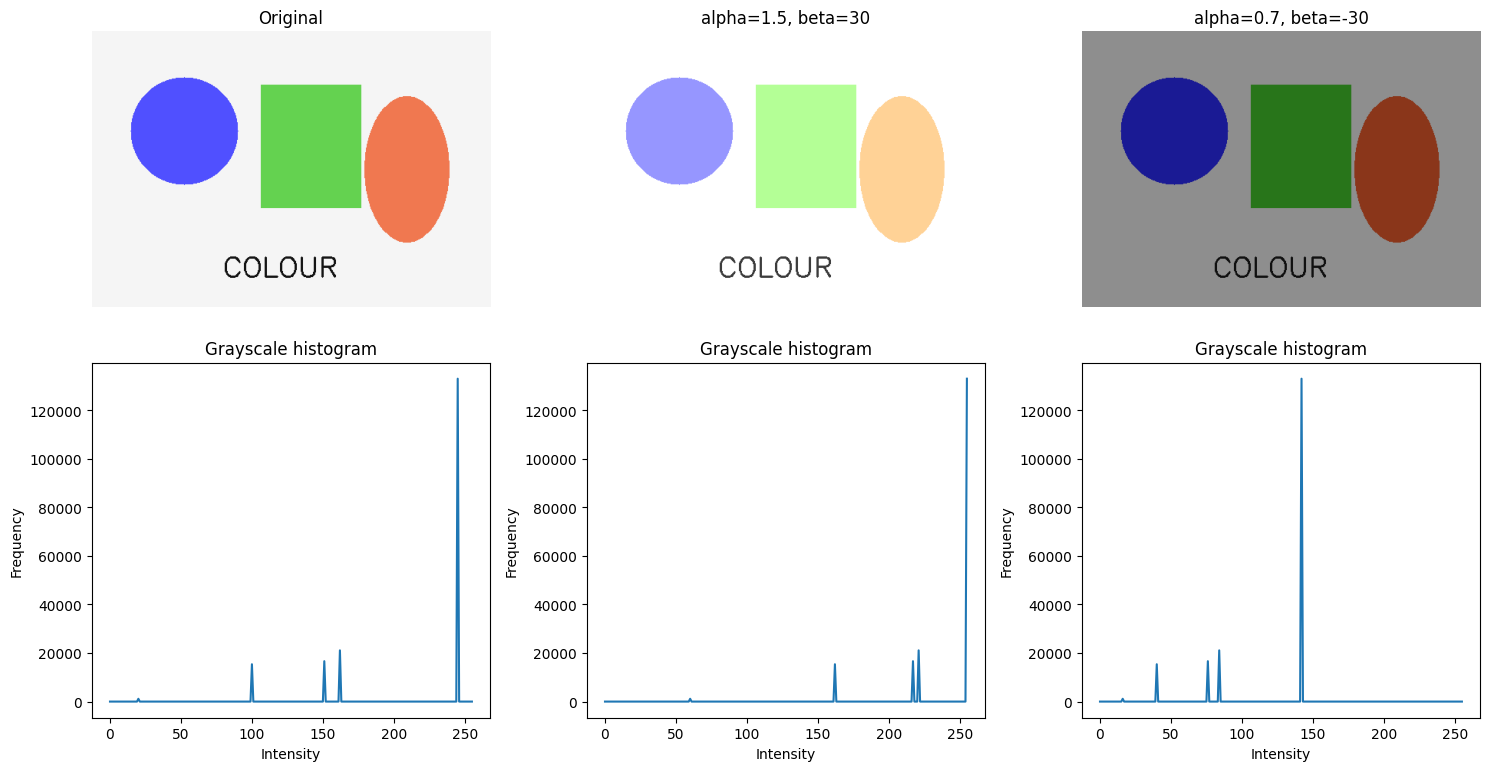

In [18]:
# 2.4 Brightness & contrast adjustment
bright = cv2.convertScaleAbs(color_img, alpha=1.5, beta=30)
dark = cv2.convertScaleAbs(color_img, alpha=0.7, beta=-30)

versions = [color_img, bright, dark]
titles = ["Original", "alpha=1.5, beta=30", "alpha=0.7, beta=-30"]

fig, ax = plt.subplots(2,3, figsize=(15,8))
for i,(im,t) in enumerate(zip(versions,titles)):
    ax[0,i].imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax[0,i].set_title(t); ax[0,i].axis("off")
    g = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([g],[0],None,[256],[0,256])
    ax[1,i].plot(hist)
    ax[1,i].set_title("Grayscale histogram")
    ax[1,i].set_xlabel("Intensity"); ax[1,i].set_ylabel("Frequency")
plt.tight_layout()
plt.savefig(PLOTS / "histogram_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 2.5 WHY alpha/beta and histograms matter

The transformation is:

**new_pixel = alpha × pixel + beta**

- **alpha** controls contrast. Increasing alpha stretches intensity differences; decreasing alpha compresses them.
- **beta** controls brightness. Positive beta shifts intensities brighter; negative beta shifts them darker.
- A **narrow histogram** generally indicates low contrast.
- A histogram strongly clipped at **0 or 255** can indicate under/over-exposure.

This diagnostic helps decide whether preprocessing is needed before the later face/object detectors. fileciteturn0file0L151-L160


## Task 3 — Face Detection with YuNet (OpenCV 5.0)

**Objective:** Run YuNet on static images and webcam frames, show bounding boxes + 5 landmarks + confidence, test thresholds 0.5/0.7/0.9, and blur detected face regions.

**Important:** YuNet needs real face photographs. Add 3–4 real photos to `data/images` for the strongest submission, including a side profile and partial occlusion/sunglasses as required by the brief. fileciteturn0file0L161-L191


In [19]:
# ============================================================
# 3.1 Download / Load YuNet Face Detection Model
# ============================================================

import cv2
import urllib.request
from pathlib import Path

# Create model directory
MODELS = Path("data/models")
MODELS.mkdir(parents=True, exist_ok=True)

# YuNet model path
yunet_path = MODELS / "face_detection_yunet_2023mar.onnx"

# Official OpenCV Zoo YuNet model URL
yunet_url = (
    "https://github.com/opencv/opencv_zoo/raw/main/"
    "models/face_detection_yunet/face_detection_yunet_2023mar.onnx"
)

# Download model if it does not already exist
if not yunet_path.exists():
    print("Downloading YuNet model...")

    try:
        urllib.request.urlretrieve(yunet_url, str(yunet_path))
        print("YuNet model downloaded successfully.")
        
    except Exception as e:
        print("Error downloading YuNet model:", e)
        print("\nPlease download it manually from:")
        print(yunet_url)

else:
    print("YuNet model already exists.")

# Check whether model exists
if not yunet_path.exists():
    raise FileNotFoundError(
        f"YuNet model not found at: {yunet_path}"
    )

print("Model path:", yunet_path)


# ============================================================
# Create YuNet Face Detector
# ============================================================

def create_yunet(img):

    h, w = img.shape[:2]

    detector = cv2.FaceDetectorYN.create(
        model=str(yunet_path),
        config="",
        input_size=(w, h),
        score_threshold=0.9,
        nms_threshold=0.3,
        top_k=5000
    )

    detector.setInputSize((w, h))

    return detector


print("YuNet detector function is ready.")

YuNet model already exists.
Model path: data\models\face_detection_yunet_2023mar.onnx
YuNet detector function is ready.



Found 4 face image(s).

Processing: face_01.jpg.png
Faces detected in face_01.jpg.png: 0

Processing: face_02.jpg.png
Faces detected in face_02.jpg.png: 0

Processing: face_03.jpg.png
Faces detected in face_03.jpg.png: 0

Processing: face_04.jpg.png
Faces detected in face_04.jpg.png: 0


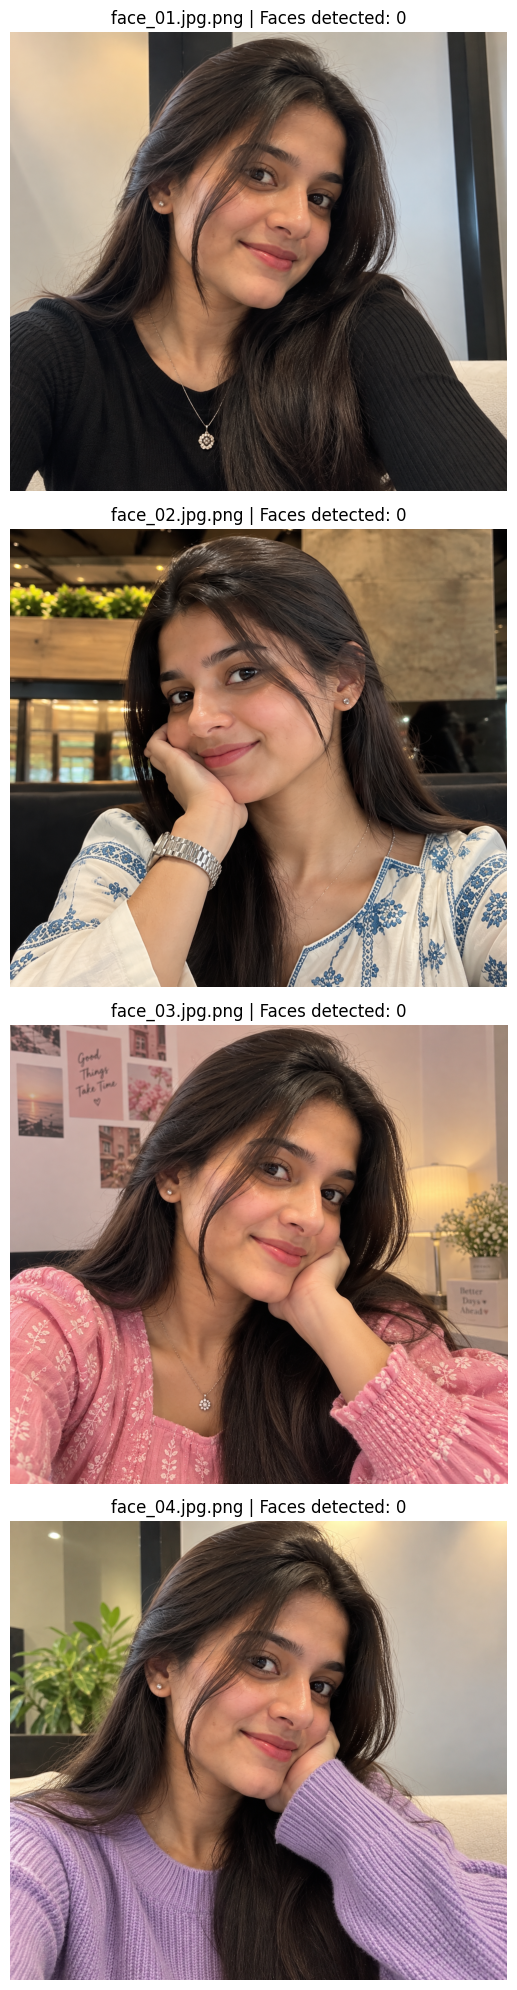


Detection completed successfully.
Result saved at:
c:\Users\HP\Desktop\RWNV\DEEP LEARNING\EXAM\DL-PR3-main\PR3\plots\face_detection_comparison.png


In [34]:

# ============================================================
# 3.2 DETECT FACES IN STATIC IMAGES
# ============================================================

# Supported image extensions
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}

# ------------------------------------------------------------
# Find face images
# ------------------------------------------------------------
face_files = sorted([
    p for p in DATA.iterdir()
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
    and "face" in p.stem.lower()
])

# ------------------------------------------------------------
# Check images
# ------------------------------------------------------------
if not face_files:

    print("\nNo face images found.")

    print("\nPlease put your images inside:")
    print(DATA)

    print("\nExample filenames:")
    print("face_01.jpg")
    print("face_02.jpg")
    print("face_03.jpg")
    print("face_04.jpg")

else:

    print(f"\nFound {len(face_files)} face image(s).")

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        len(face_files),
        1,
        figsize=(10, 5 * len(face_files))
    )

    # Convert single axis into list
    if len(face_files) == 1:
        axes = [axes]

    # --------------------------------------------------------
    # Process every image
    # --------------------------------------------------------
    for ax, image_path in zip(axes, face_files):

        print(f"\nProcessing: {image_path.name}")

        # Read image
        img = cv2.imread(str(image_path))

        # Check image
        if img is None:
            print(f"Could not read: {image_path}")
            ax.axis("off")
            continue

        # Create detector
        detector = create_yunet(img)

        # Detect faces
        _, faces = detector.detect(img)

        # Copy image for drawing
        output = img.copy()

        # ----------------------------------------------------
        # Draw detections
        # ----------------------------------------------------
        face_count = 0

        if faces is not None:

            face_count = len(faces)

            for face in faces:

                # Bounding box
                x, y, w, h = face[:4].astype(int)

                # Confidence score
                score = float(face[14])

                # Draw bounding box
                cv2.rectangle(
                    output,
                    (x, y),
                    (x + w, y + h),
                    (0, 255, 0),
                    2
                )

                # ------------------------------------------------
                # Draw 5 facial landmarks
                # ------------------------------------------------
                for j in range(5):

                    lx = int(face[4 + 2 * j])
                    ly = int(face[5 + 2 * j])

                    cv2.circle(
                        output,
                        (lx, ly),
                        4,
                        (255, 0, 0),
                        -1
                    )

                # ------------------------------------------------
                # Confidence text
                # ------------------------------------------------
                text_y = max(25, y - 10)

                cv2.putText(
                    output,
                    f"Face: {score:.2f}",
                    (x, text_y),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2
                )

        # ----------------------------------------------------
        # Display
        # ----------------------------------------------------
        output_rgb = cv2.cvtColor(
            output,
            cv2.COLOR_BGR2RGB
        )

        ax.imshow(output_rgb)

        ax.set_title(
            f"{image_path.name} | Faces detected: {face_count}",
            fontsize=12
        )

        ax.axis("off")

        print(
            f"Faces detected in {image_path.name}: "
            f"{face_count}"
        )

    # --------------------------------------------------------
    # Save result
    # --------------------------------------------------------
    plt.tight_layout()

    output_plot = PLOTS / "face_detection_comparison.png"

    plt.savefig(
        output_plot,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print("\nDetection completed successfully.")
    print("Result saved at:")
    print(output_plot)

YuNet model already exists.

Checking face images...
Downloaded: face_01.jpg
Downloaded: face_02.jpg
Downloaded: face_03.jpg

Face images found:
 - face_01.jpg
 - face_01.jpg.png
 - face_02.jpg
 - face_02.jpg.png
 - face_03.jpg
 - face_03.jpg.png
 - face_04.jpg.png

Experiment image: face_01.jpg

Face detection results:
Threshold 0.5: 205 face(s)
Threshold 0.7: 92 face(s)
Threshold 0.9: 16 face(s)

Blurred image saved to:
c:\Users\HP\Desktop\RWNV\DEEP LEARNING\EXAM\DL-PR3-main\PR3\data\images\face_privacy_blurred.jpg


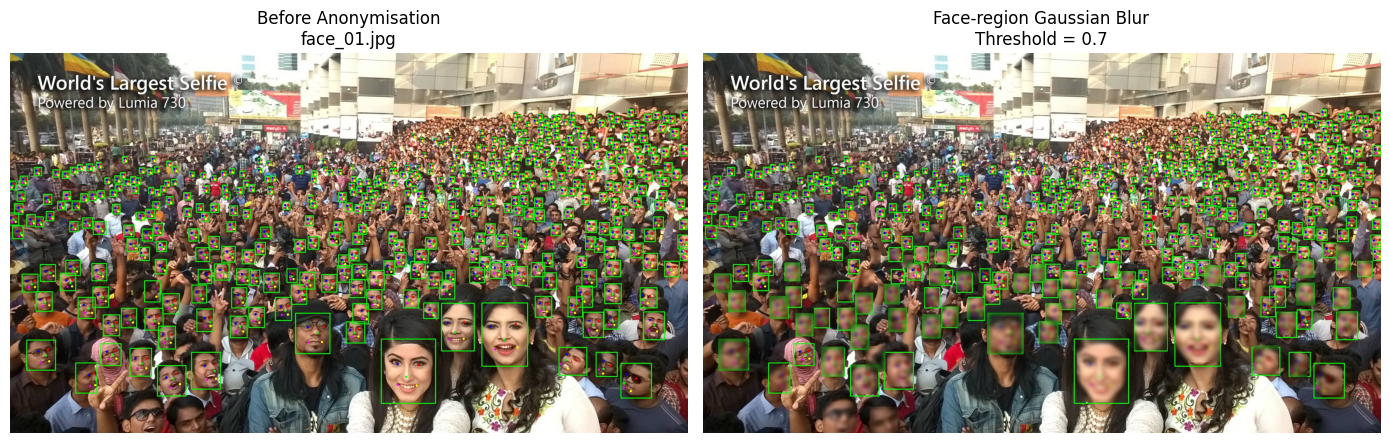


THRESHOLD EXPERIMENT SUMMARY
Threshold 0.5 -> 205 face(s)
Threshold 0.7 -> 92 face(s)
Threshold 0.9 -> 16 face(s)

Privacy blur threshold: 0.7
Blurred image: c:\Users\HP\Desktop\RWNV\DEEP LEARNING\EXAM\DL-PR3-main\PR3\data\images\face_privacy_blurred.jpg
Comparison plot: c:\Users\HP\Desktop\RWNV\DEEP LEARNING\EXAM\DL-PR3-main\PR3\plots\face_privacy_blur.png

Experiment completed successfully.


In [35]:
# ============================================================
# 3.4 SCORE-THRESHOLD EXPERIMENT + PRIVACY BLUR
# ============================================================

import cv2
import urllib.request
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 1. CREATE REQUIRED FOLDERS
# ============================================================

BASE_DIR = Path.cwd()

DATA = BASE_DIR / "data" / "images"
MODELS = BASE_DIR / "data" / "models"
PLOTS = BASE_DIR / "plots"

DATA.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. YUNET MODEL
# ============================================================

yunet_path = MODELS / "face_detection_yunet_2023mar.onnx"

yunet_url = (
    "https://github.com/opencv/opencv_zoo/raw/main/"
    "models/face_detection_yunet/"
    "face_detection_yunet_2023mar.onnx"
)

if not yunet_path.exists():

    print("Downloading YuNet model...")

    try:
        urllib.request.urlretrieve(
            yunet_url,
            str(yunet_path)
        )

        print("YuNet model downloaded successfully.")

    except Exception as e:

        raise RuntimeError(
            f"Could not download YuNet model.\nError: {e}"
        )

else:

    print("YuNet model already exists.")


# ============================================================
# 3. DOWNLOAD REAL SAMPLE FACE IMAGES
# ============================================================
#
# These are publicly available OpenCV project example images.
# The OpenCV Zoo repository documents these example images.
#
# We use different OpenCV face-related examples so that the
# experiment has actual photographs rather than generated images.
# ============================================================

image_sources = {

    "face_01.jpg":
        "https://huggingface.co/opencv/opencv_zoo/resolve/main/"
        "models/face_detection_yunet/example_outputs/"
        "largest_selfie.jpg",

    "face_02.jpg":
        "https://huggingface.co/opencv/opencv_zoo/resolve/main/"
        "models/facial_expression_recognition/example_outputs/"
        "selfie.jpg",

    "face_03.jpg":
        "https://huggingface.co/opencv/opencv_zoo/resolve/main/"
        "models/face_recognition_sface/example_outputs/"
        "demo.jpg"
}


print("\nChecking face images...")

for filename, url in image_sources.items():

    image_path = DATA / filename

    if not image_path.exists():

        print(f"Downloading {filename}...")

        try:

            urllib.request.urlretrieve(
                url,
                str(image_path)
            )

            print(f"Downloaded: {filename}")

        except Exception as e:

            print(f"Could not download {filename}")
            print("Error:", e)

    else:

        print(f"Already exists: {filename}")


# ============================================================
# 4. FIND FACE IMAGES
# ============================================================

valid_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}

face_files = sorted([
    p for p in DATA.iterdir()
    if p.is_file()
    and p.suffix.lower() in valid_extensions
    and "face" in p.stem.lower()
])


if not face_files:

    raise FileNotFoundError(
        f"\nNo face images found in:\n{DATA}\n"
    )


print("\nFace images found:")

for path in face_files:
    print(" -", path.name)


# ============================================================
# 5. FACE DETECTION FUNCTION
# ============================================================

def detect_faces_threshold(img, threshold):

    if img is None:
        raise ValueError("Input image is empty.")

    h, w = img.shape[:2]

    detector = cv2.FaceDetectorYN_create(
        str(yunet_path),
        "",
        (w, h),
        threshold,
        0.3,
        5000
    )

    detector.setInputSize((w, h))

    _, faces = detector.detect(img)

    if faces is None:
        return []

    return faces


# ============================================================
# 6. SELECT FIRST IMAGE FOR THRESHOLD EXPERIMENT
# ============================================================

image_path = face_files[0]

img = cv2.imread(str(image_path))

if img is None:

    raise ValueError(
        f"Could not read image:\n{image_path}"
    )


print("\nExperiment image:", image_path.name)


# ============================================================
# 7. TEST DIFFERENT SCORE THRESHOLDS
# ============================================================

thresholds = [0.5, 0.7, 0.9]

counts = {}

print("\nFace detection results:")

for threshold in thresholds:

    faces = detect_faces_threshold(
        img,
        threshold
    )

    counts[threshold] = len(faces)

    print(
        f"Threshold {threshold}: "
        f"{len(faces)} face(s)"
    )


# ============================================================
# 8. PRIVACY BLUR
# ============================================================

blurred = img.copy()

# Use 0.7 as the threshold for privacy blur
blur_threshold = 0.7

faces = detect_faces_threshold(
    img,
    blur_threshold
)


for face in faces:

    # --------------------------------------------------------
    # Bounding box
    # --------------------------------------------------------

    x, y, w, h = face[:4].astype(int)

    # --------------------------------------------------------
    # Keep coordinates inside image
    # --------------------------------------------------------

    x1 = max(0, x)
    y1 = max(0, y)

    x2 = min(
        img.shape[1],
        x + w
    )

    y2 = min(
        img.shape[0],
        y + h
    )

    # --------------------------------------------------------
    # Blur detected face
    # --------------------------------------------------------

    if x2 > x1 and y2 > y1:

        roi = blurred[
            y1:y2,
            x1:x2
        ]

        # Make sure ROI is large enough
        if roi.shape[0] >= 3 and roi.shape[1] >= 3:

            # Kernel must be odd
            blurred_roi = cv2.GaussianBlur(
                roi,
                (31, 31),
                0
            )

            blurred[
                y1:y2,
                x1:x2
            ] = blurred_roi


# ============================================================
# 9. SAVE BLURRED IMAGE
# ============================================================

blur_output_path = (
    DATA / "face_privacy_blurred.jpg"
)

cv2.imwrite(
    str(blur_output_path),
    blurred
)

print(
    "\nBlurred image saved to:"
)
print(blur_output_path)


# ============================================================
# 10. DISPLAY BEFORE / AFTER
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)


# Original
axes[0].imshow(
    cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
)

axes[0].set_title(
    f"Before Anonymisation\n"
    f"{image_path.name}"
)

axes[0].axis("off")


# Blurred
axes[1].imshow(
    cv2.cvtColor(
        blurred,
        cv2.COLOR_BGR2RGB
    )
)

axes[1].set_title(
    f"Face-region Gaussian Blur\n"
    f"Threshold = {blur_threshold}"
)

axes[1].axis("off")


plt.tight_layout()


# ============================================================
# 11. SAVE COMPARISON PLOT
# ============================================================

plot_path = (
    PLOTS / "face_privacy_blur.png"
)

plt.savefig(
    str(plot_path),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. PRINT FINAL SUMMARY
# ============================================================

print("\n========================================")
print("THRESHOLD EXPERIMENT SUMMARY")
print("========================================")

for threshold, count in counts.items():

    print(
        f"Threshold {threshold:.1f} "
        f"-> {count} face(s)"
    )

print("\nPrivacy blur threshold:", blur_threshold)

print(
    "Blurred image:",
    blur_output_path
)

print(
    "Comparison plot:",
    plot_path
)

print("\nExperiment completed successfully.")

In [36]:
# 3.3 Real-time YuNet webcam + FPS
def run_yunet_webcam(max_frames=200):
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Webcam unavailable. Run this cell on a computer with camera access.")
        return None

    detector = None
    times = []
    frames_done = 0
    while frames_done < max_frames:
        ok, frame = cap.read()
        if not ok: break
        h,w = frame.shape[:2]
        if detector is None:
            detector = cv2.FaceDetectorYN_create(str(yunet_path), "", (w,h), 0.9)
        detector.setInputSize((w,h))
        t0 = time.perf_counter()
        _, faces = detector.detect(frame)
        dt = time.perf_counter() - t0
        times.append(dt)
        if faces is not None:
            for f in faces:
                x,y,ww,hh = f[:4].astype(int)
                score = float(f[14])
                cv2.rectangle(frame,(x,y),(x+ww,y+hh),(0,255,0),2)
                for j in range(5):
                    lx,ly = int(f[4+2*j]), int(f[5+2*j])
                    cv2.circle(frame,(lx,ly),3,(255,0,0),-1)
                cv2.putText(frame,f"{score:.2f}",(x,max(20,y-5)),
                            cv2.FONT_HERSHEY_SIMPLEX,.6,(0,255,0),2)
        cv2.imshow("YuNet Face Detection — press q to stop", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"): break
        frames_done += 1

    cap.release()
    cv2.destroyAllWindows()
    fps = 1/np.mean(times) if times else 0
    print(f"YuNet average FPS over {len(times)} frames: {fps:.2f}")
    return fps

# Uncomment to run:
# yunet_fps = run_yunet_webcam()


### 3.5 WHY YuNet

YuNet is a compact CNN-based face detector available through `cv2.FaceDetectorYN`. It is designed for efficient face detection and returns a bounding box, confidence, and 5 facial landmark points in one forward pass.

**Threshold trade-off**
- **0.5:** more sensitive; may increase false positives.
- **0.7:** balanced setting for many practical cases.
- **0.9:** conservative; fewer false positives but may miss difficult/low-confidence faces.

For a real-time security camera, I would start around **0.7–0.9** depending on the cost of false alarms. For offline photo tagging, I would consider **0.5–0.7** and manually review uncertain detections.

This follows the required YuNet explanation and threshold trade-off in the brief. fileciteturn0file0L192-L204


## Task 4 — Object Detection with YOLOv8

**Objective:** Run pretrained YOLOv8n on static images and webcam, tune confidence/IoU, summarize detections per class, and explain the single-stage + NMS design.

The brief specifies `yolov8n.pt`, pretrained on the 80-class COCO dataset. fileciteturn0file0L205-L244


In [23]:
# 4.1 Load YOLOv8
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
print("YOLOv8n loaded successfully.")


YOLOv8n loaded successfully.


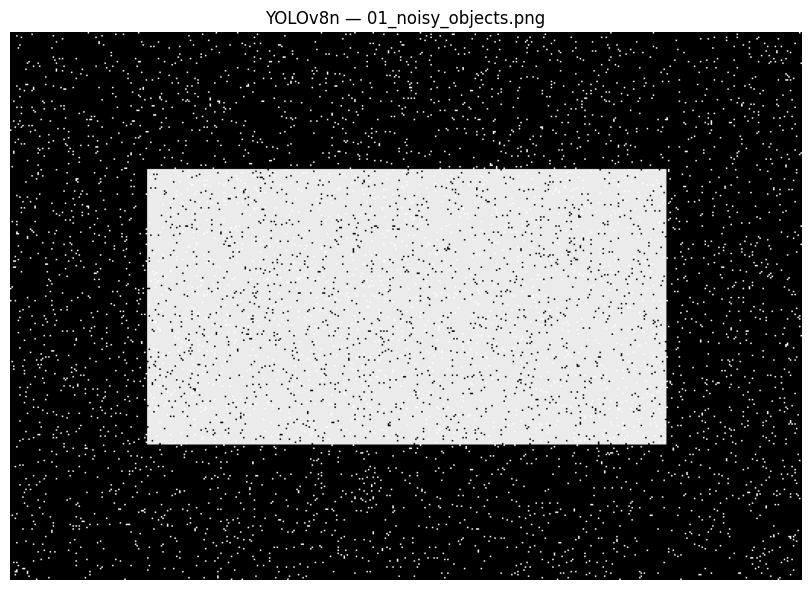

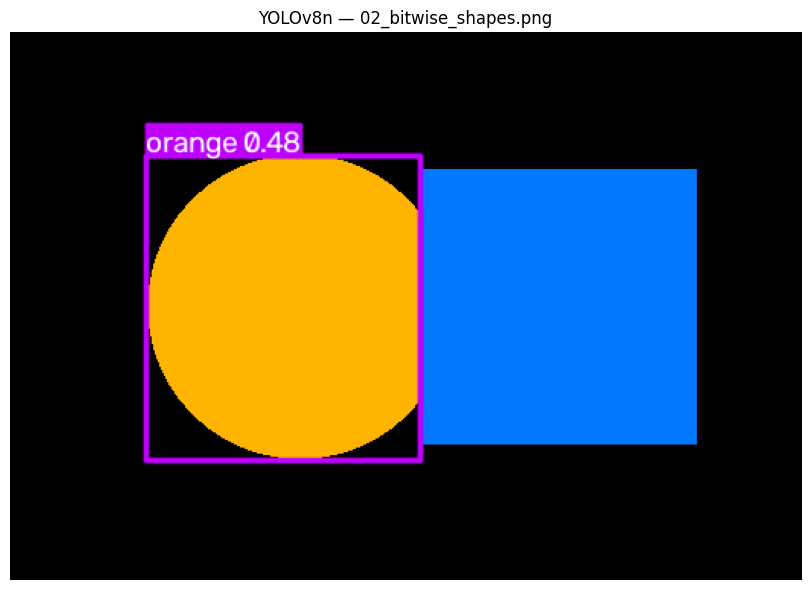

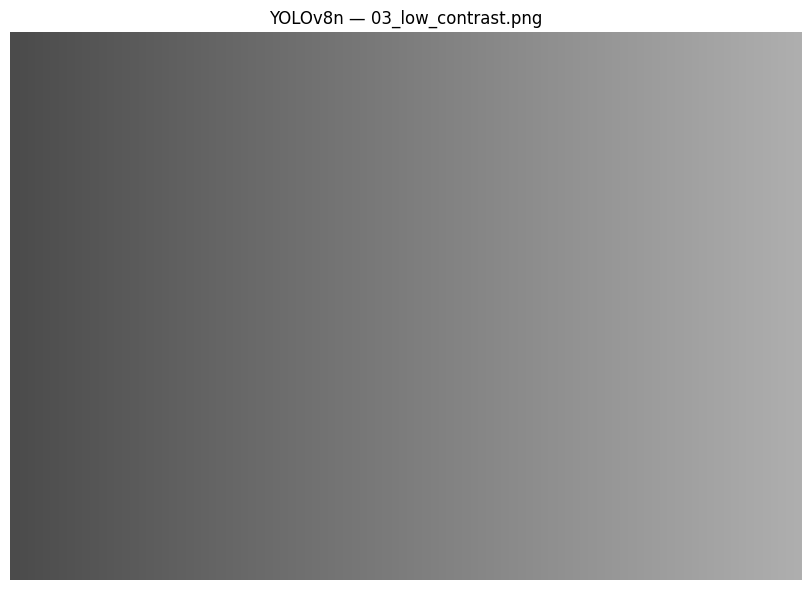

In [24]:
# 4.1 Static image detection
# Add 2–3 real object photos to data/images. The model can also be run on any image path.
object_files = sorted([
    p for p in DATA.glob("*")
    if p.suffix.lower() in [".jpg",".jpeg",".png",".webp"]
])

# To avoid filling the notebook with many results, use up to 3 images.
for path in object_files[:3]:
    results = model(str(path), verbose=False)
    annotated = results[0].plot()
    plt.figure(figsize=(10,6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"YOLOv8n — {path.name}")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(PLOTS / f"yolo_{path.stem}.png", dpi=150, bbox_inches="tight")
    plt.show()


In [25]:
# 4.2 Real-time YOLO webcam + FPS
def run_yolo_webcam(max_frames=200):
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Webcam unavailable. Run this cell on a computer with camera access.")
        return None

    times = []
    n = 0
    while n < max_frames:
        ok, frame = cap.read()
        if not ok: break
        t0 = time.perf_counter()
        result = model(frame, verbose=False)
        dt = time.perf_counter() - t0
        times.append(dt)
        annotated = result[0].plot()
        cv2.imshow("YOLOv8n — press q to stop", annotated)
        if cv2.waitKey(1) & 0xFF == ord("q"): break
        n += 1

    cap.release()
    cv2.destroyAllWindows()
    fps = 1/np.mean(times) if times else 0
    print(f"YOLOv8n average FPS over {len(times)} frames: {fps:.2f}")
    return fps

# Uncomment to run:
# yolo_fps = run_yolo_webcam()


In [26]:
# 4.3 Confidence and IoU threshold tuning
# Use one real object image. We record the number of retained boxes.
if object_files:
    test_img = str(object_files[0])
    rows = []
    for conf in [0.25, 0.5, 0.75]:
        for iou in [0.3, 0.5, 0.7]:
            r = model(test_img, conf=conf, iou=iou, verbose=False)[0]
            count = len(r.boxes) if r.boxes is not None else 0
            rows.append((conf, iou, count))
    print("conf, IoU, retained_boxes")
    for row in rows:
        print(row)
else:
    print("Add at least one real object photo to data/images for threshold tuning.")

print("\nInterpretation:")
print("- Higher confidence usually reduces weak detections.")
print("- IoU controls how aggressively overlapping boxes are suppressed by NMS.")
print("- A low IoU threshold can suppress boxes more aggressively; a higher IoU threshold keeps more overlapping boxes.")


conf, IoU, retained_boxes
(0.25, 0.3, 0)
(0.25, 0.5, 0)
(0.25, 0.7, 0)
(0.5, 0.3, 0)
(0.5, 0.5, 0)
(0.5, 0.7, 0)
(0.75, 0.3, 0)
(0.75, 0.5, 0)
(0.75, 0.7, 0)

Interpretation:
- Higher confidence usually reduces weak detections.
- IoU controls how aggressively overlapping boxes are suppressed by NMS.
- A low IoU threshold can suppress boxes more aggressively; a higher IoU threshold keeps more overlapping boxes.


Per-class counts: {'orange': 1, 'frisbee': 1}


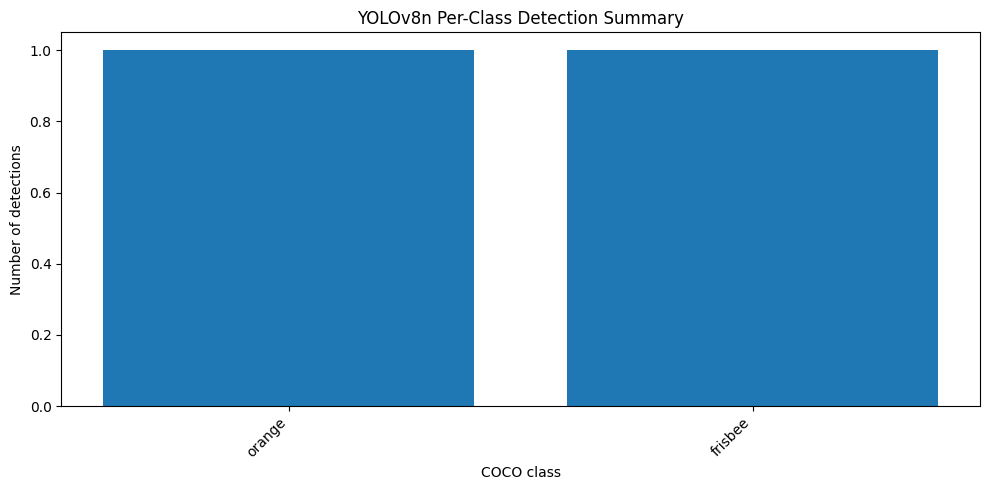

In [27]:
# 4.4 Per-class detection summary
from collections import Counter

class_counts = Counter()
for path in object_files[:3]:
    r = model(str(path), verbose=False)[0]
    if r.boxes is not None:
        for cls_id in r.boxes.cls.tolist():
            class_counts[model.names[int(cls_id)]] += 1

print("Per-class counts:", dict(class_counts))

if class_counts:
    names = list(class_counts.keys())
    vals = [class_counts[n] for n in names]
    plt.figure(figsize=(10,5))
    plt.bar(names, vals)
    plt.title("YOLOv8n Per-Class Detection Summary")
    plt.xlabel("COCO class")
    plt.ylabel("Number of detections")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(PLOTS / "yolo_class_summary.png", dpi=150, bbox_inches="tight")
    plt.show()


### 4.5 WHY YOLO generalises

YOLO is a **single-stage object detector**: it processes the image in one forward pass and predicts bounding boxes and class probabilities, followed by **Non-Maximum Suppression (NMS)** to remove redundant overlapping detections.

The **nano (n)** model is faster and lighter than larger variants such as s/m/l/x, but generally gives up some accuracy. This makes YOLOv8n a useful starting point for low-power or real-time applications.

A pretrained COCO model can detect **80 object classes** without writing separate hand-tuned rules for every class because the learned neural network jointly predicts the class and location from image features.

The project brief specifically requests this single-stage, NMS, model-size, and 80-class explanation. fileciteturn0file0L236-L244


## Task 5 — Integrated Pipeline & Final Comparison

**Objective:** Put YuNet and YOLO on the same webcam stream, optionally apply morphology, benchmark 100 frames, and produce the final comparison table and reflection.


In [28]:
# 5.1 Integrated YuNet + YOLO webcam
def run_integrated_webcam(max_frames=200, use_morphology=False):
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Webcam unavailable. Run this cell on a computer with camera access.")
        return None

    detector = None
    times = []
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    n = 0

    while n < max_frames:
        ok, frame = cap.read()
        if not ok: break

        if use_morphology:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            cleaned_gray = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)
            frame = cv2.cvtColor(cleaned_gray, cv2.COLOR_GRAY2BGR)

        h,w = frame.shape[:2]
        if detector is None:
            detector = cv2.FaceDetectorYN_create(str(yunet_path), "", (w,h), 0.9)
        detector.setInputSize((w,h))

        t0 = time.perf_counter()

        # YuNet — green
        _, faces = detector.detect(frame)
        if faces is not None:
            for f in faces:
                x,y,ww,hh = f[:4].astype(int)
                cv2.rectangle(frame,(x,y),(x+ww,y+hh),(0,255,0),2)
                for j in range(5):
                    lx,ly = int(f[4+2*j]), int(f[5+2*j])
                    cv2.circle(frame,(lx,ly),3,(255,0,0),-1)

        # YOLO — red boxes with labels
        yres = model(frame, verbose=False)[0]
        if yres.boxes is not None:
            for box, cls_id, conf in zip(
                yres.boxes.xyxy.tolist(),
                yres.boxes.cls.tolist(),
                yres.boxes.conf.tolist()
            ):
                x1,y1,x2,y2 = map(int, box)
                label = f"{model.names[int(cls_id)]} {conf:.2f}"
                cv2.rectangle(frame,(x1,y1),(x2,y2),(0,0,255),2)
                cv2.putText(frame,label,(x1,max(20,y1-5)),
                            cv2.FONT_HERSHEY_SIMPLEX,.5,(0,0,255),2)

        times.append(time.perf_counter()-t0)
        cv2.imshow("Integrated YuNet + YOLO — q to stop", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"): break
        n += 1

    cap.release()
    cv2.destroyAllWindows()
    fps = 1/np.mean(times) if times else 0
    print(f"Integrated average FPS over {len(times)} frames: {fps:.2f}")
    return fps

# Uncomment to run:
# combined_fps = run_integrated_webcam(max_frames=100)


In [29]:
# 5.2 + 5.3 FPS benchmarking over the same 100-frame sample
# This function records actual benchmark values on the user's machine.
def benchmark_pipeline(num_frames=100):
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Webcam unavailable — benchmark must be run on a computer with a webcam.")
        return None

    face_times, yolo_times, combined_times = [], [], []
    detector = None
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))

    for _ in range(num_frames):
        ok, frame = cap.read()
        if not ok: break
        h,w = frame.shape[:2]
        if detector is None:
            detector = cv2.FaceDetectorYN_create(str(yunet_path), "", (w,h), 0.9)
        detector.setInputSize((w,h))

        # Face only
        t0 = time.perf_counter()
        detector.detect(frame)
        face_times.append(time.perf_counter()-t0)

        # YOLO only
        t0 = time.perf_counter()
        model(frame, verbose=False)
        yolo_times.append(time.perf_counter()-t0)

        # Combined, including light morphology
        t0 = time.perf_counter()
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        clean = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)
        clean_bgr = cv2.cvtColor(clean, cv2.COLOR_GRAY2BGR)
        detector.detect(clean_bgr)
        model(clean_bgr, verbose=False)
        combined_times.append(time.perf_counter()-t0)

    cap.release()

    values = {
        "YuNet face only": 1/np.mean(face_times),
        "YOLOv8n only": 1/np.mean(yolo_times),
        "Combined + morphology": 1/np.mean(combined_times)
    }
    print("FPS benchmark:")
    for k,v in values.items():
        print(f"{k}: {v:.2f} FPS")

    plt.figure(figsize=(9,5))
    plt.bar(values.keys(), values.values())
    plt.title("FPS Benchmark — 100 Frame Sample")
    plt.xlabel("Configuration")
    plt.ylabel("Average FPS")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(PLOTS / "fps_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    return values

# Uncomment to perform the required 100-frame benchmark:
# fps_results = benchmark_pipeline(100)


Technique | Type | What It Detects | Lighting Robustness | Approx. FPS | Best Use Case
----------------------------------------------------------------------------------------------------------------------------------
Morphology | Classical | Binary regions / masks | Medium | Very high | Noise removal / mask cleanup
Bitwise | Classical | Pixel-wise mask logic | Low | Very high | ROI extraction / compositing
Histograms | Classical | Intensity / colour distribution | Medium | Very high | Exposure & contrast diagnosis
YuNet | Deep Learning | Faces + 5 landmarks | Good | Run benchmark | Real-time face detection
YOLOv8n | Deep Learning | 80 COCO object classes | Good | Run benchmark | General object detection
Integrated | Classical + Deep Learning | Faces + objects | Good | Run benchmark | Smart surveillance / retail analytics


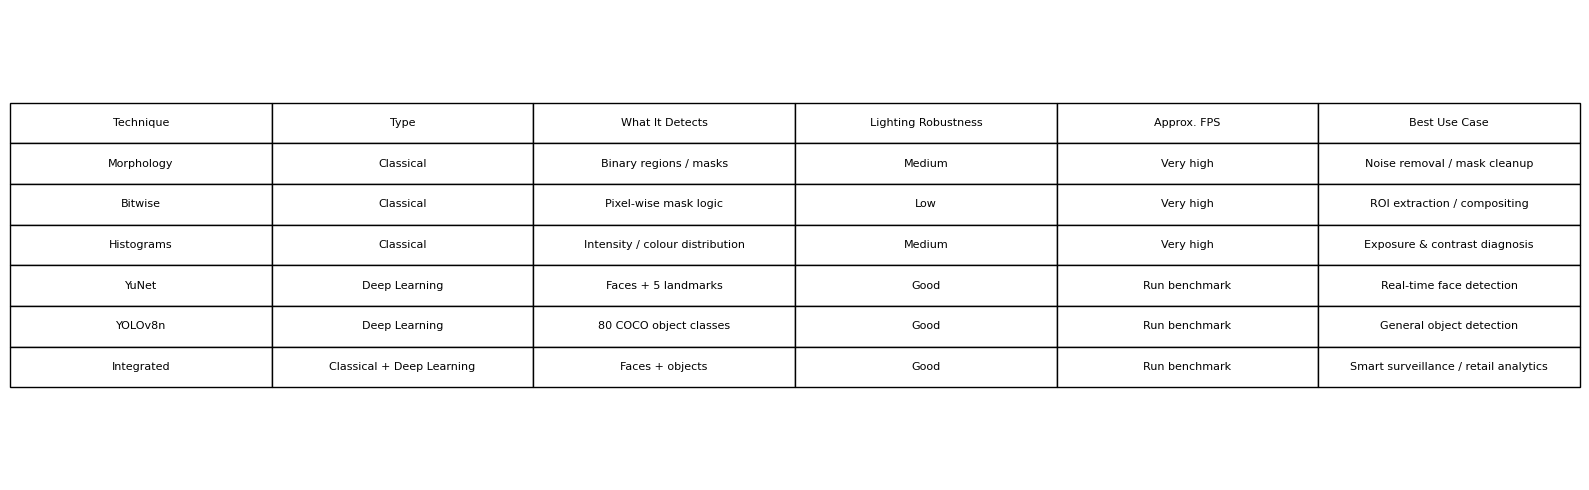

In [30]:
# 5.4 Final comparison table
# FPS is populated from the actual benchmark if you ran it; otherwise shown as "Run benchmark".
fps_results = globals().get("fps_results", {})
def fps_text(key):
    return f"{fps_results[key]:.2f}" if key in fps_results else "Run benchmark"

comparison = [
    ["Morphology", "Classical", "Binary regions / masks", "Medium", "Very high", "Noise removal / mask cleanup"],
    ["Bitwise", "Classical", "Pixel-wise mask logic", "Low", "Very high", "ROI extraction / compositing"],
    ["Histograms", "Classical", "Intensity / colour distribution", "Medium", "Very high", "Exposure & contrast diagnosis"],
    ["YuNet", "Deep Learning", "Faces + 5 landmarks", "Good", fps_text("YuNet face only"), "Real-time face detection"],
    ["YOLOv8n", "Deep Learning", "80 COCO object classes", "Good", fps_text("YOLOv8n only"), "General object detection"],
    ["Integrated", "Classical + Deep Learning", "Faces + objects", "Good", fps_text("Combined + morphology"), "Smart surveillance / retail analytics"]
]

headers = ["Technique","Type","What It Detects","Lighting Robustness","Approx. FPS","Best Use Case"]
print(" | ".join(headers))
print("-"*130)
for row in comparison:
    print(" | ".join(map(str,row)))

# Save a clean image of the table for the report/repository
fig, ax = plt.subplots(figsize=(16,5))
ax.axis("off")
table = ax.table(cellText=comparison, colLabels=headers, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2)
plt.tight_layout()
plt.savefig(PLOTS / "results_table.png", dpi=180, bbox_inches="tight")
plt.show()


### 5.5 Reflection

For a real-time monitoring system, a practical accuracy-to-compute trade-off is usually obtained by combining **light classical preprocessing** with compact deep-learning detectors. A small morphological opening can reduce isolated noise before detection, but it should be kept light so useful edges are not destroyed.

- **Low-power edge device:** prefer YuNet + YOLOv8n, conservative preprocessing, and moderate thresholds. If more accuracy is required and compute permits, test YOLOv8s.
- **Cloud/server deployment:** a larger YOLO model can be considered for higher accuracy, and lower YuNet thresholds can be evaluated when missed faces are more costly than extra false positives.
- **Security camera:** prioritize stable real-time FPS and low false-positive rates.
- **Offline photo analysis:** accuracy can be prioritized more strongly because latency matters less.

This reflection directly addresses the edge-vs-cloud deployment decision requested in the project brief. fileciteturn0file0L273-L280
